In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv(r"E:\vs\module 1\assignment 3 regularization simplified\WineQT.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
X = data.drop("quality", axis=1)
y = data["quality"]

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Features:")
print(X.columns.tolist())

Number of samples: 1143
Number of features: 12
Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [4]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].values
X_test = X.iloc[test_indices].values

y_train = y.iloc[train_indices].values
y_test = y.iloc[test_indices].values

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 914
Testing samples: 229


In [5]:

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

In [6]:
X_train_with_intercept = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_with_intercept = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

In [7]:
def ridge_regression(X, y, lam):
    I = np.eye(X.shape[1])

    # Do not regularize the intercept
    I[0, 0] = 0

    weights = np.linalg.inv(
        X.T @ X + lam * I
    ) @ X.T @ y

    return weights

In [8]:
def predict(X, weights):
    return X @ weights

In [9]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [10]:
lambdas = [0, 0.1, 1, 10]

results = []

for lam in lambdas:
    weights = ridge_regression(
        X_train_with_intercept,
        y_train,
        lam
    )

    predictions = predict(
        X_test_with_intercept,
        weights
    )

    mse = mean_squared_error(y_test, predictions)

    results.append([lam, mse])

results_df = pd.DataFrame(
    results,
    columns=["Lambda", "Test MSE"]
)

results_df

,Lambda,Test MSE
0,0.0,0.377017
1,0.1,0.377008
2,1.0,0.376922
3,10.0,0.376168


In [11]:
weights = ridge_regression(
    X_train_with_intercept,
    y_train,
    1
)

feature_names = ["Intercept"] + list(X.columns)

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": weights
})

coefficient_df

,Feature,Coefficient
0,Intercept,5.646608
1,fixed acidity,0.030425
2,volatile acidity,-0.195345
3,citric acid,-0.035821
4,residual sugar,0.007953
5,chlorides,-0.099081
6,free sulfur dioxide,0.020609
7,total sulfur dioxide,-0.089262
8,density,-0.022389
9,pH,-0.083526


In [12]:
X_train_raw = np.c_[
    np.ones(X_train.shape[0]),
    X_train
]

X_test_raw = np.c_[
    np.ones(X_test.shape[0]),
    X_test
]

weights_without_scaling = ridge_regression(
    X_train_raw,
    y_train,
    1
)

In [13]:
weights_with_scaling = ridge_regression(
    X_train_with_intercept,
    y_train,
    1
)

In [14]:
comparison = pd.DataFrame({
    "Feature": feature_names,
    "Without Scaling": weights_without_scaling,
    "With Scaling": weights_with_scaling
})

comparison

,Feature,Without Scaling,With Scaling
0,Intercept,4.114271,5.646608
1,fixed acidity,0.016123,0.030425
2,volatile acidity,-1.114646,-0.195345
3,citric acid,-0.211248,-0.035821
4,residual sugar,-0.002354,0.007953
5,chlorides,-1.223427,-0.099081
6,free sulfur dioxide,0.002030,0.020609
7,total sulfur dioxide,-0.002498,-0.089262
8,density,-0.010336,-0.022389
9,pH,-0.472710,-0.083526


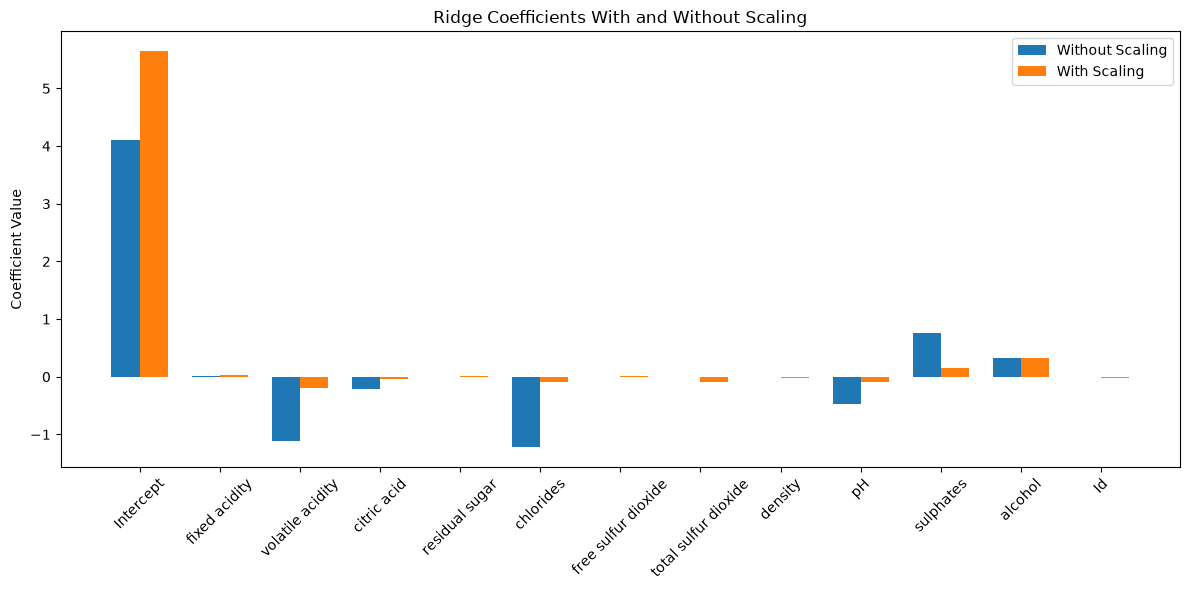

In [15]:
x = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    weights_without_scaling,
    width,
    label="Without Scaling"
)

plt.bar(
    x + width / 2,
    weights_with_scaling,
    width,
    label="With Scaling"
)

plt.xticks(x, feature_names, rotation=45)
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficients With and Without Scaling")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
lambda_values = [0, 0.001, 0.01, 0.1, 1, 10, 100]

coefficient_values = []

for lam in lambda_values:
    weights = ridge_regression(
        X_train_with_intercept,
        y_train,
        lam
    )

    coefficient_values.append(weights[1:])

coefficient_values = np.array(coefficient_values)

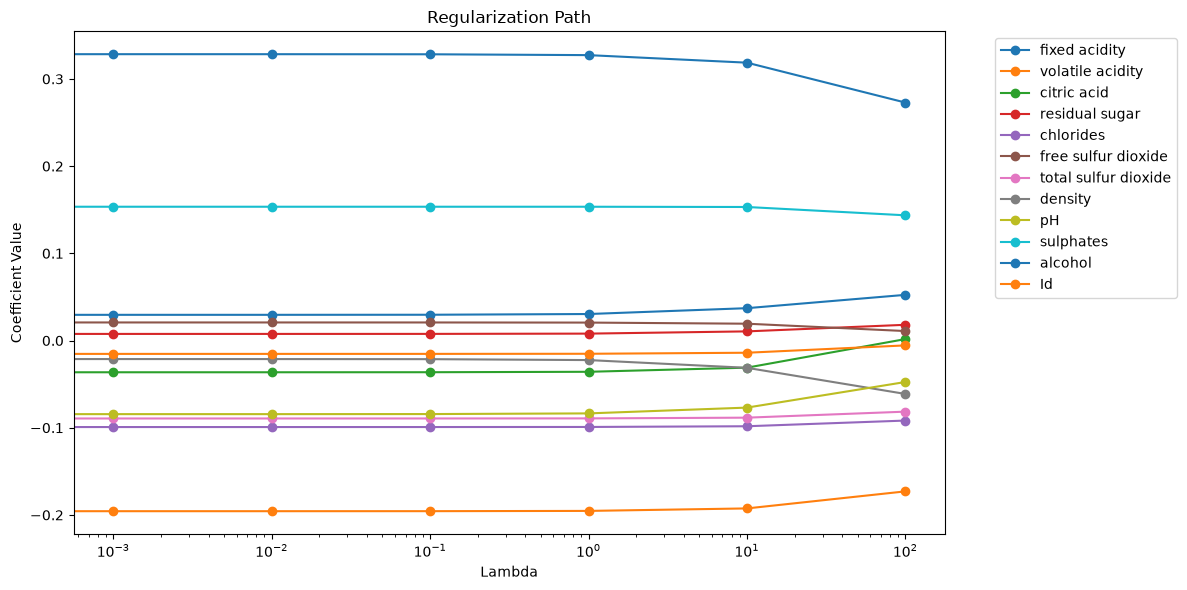

In [17]:
plt.figure(figsize=(12, 6))

for i, feature in enumerate(X.columns):
    plt.plot(
        lambda_values,
        coefficient_values[:, i],
        marker="o",
        label=feature
    )

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Coefficient Value")
plt.title("Regularization Path")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [18]:
np.random.seed(42)

indices = np.random.permutation(len(X_train_scaled))

folds = np.array_split(indices, 5)

for i, fold in enumerate(folds):
    print("Fold", i + 1, ":", len(fold), "samples")

Fold 1 : 183 samples
Fold 2 : 183 samples
Fold 3 : 183 samples
Fold 4 : 183 samples
Fold 5 : 182 samples


In [19]:
lambda_values = [0, 0.001, 0.01, 0.1, 1, 10]

cv_results = []

for lam in lambda_values:

    fold_errors = []

    for i in range(5):

        validation_indices = folds[i]

        training_indices = np.concatenate(
            [folds[j] for j in range(5) if j != i]
        )

        X_cv_train = X_train_scaled[training_indices]
        y_cv_train = y_train[training_indices]

        X_cv_val = X_train_scaled[validation_indices]
        y_cv_val = y_train[validation_indices]

        X_cv_train = np.c_[
            np.ones(X_cv_train.shape[0]),
            X_cv_train
        ]

        X_cv_val = np.c_[
            np.ones(X_cv_val.shape[0]),
            X_cv_val
        ]

        weights = ridge_regression(
            X_cv_train,
            y_cv_train,
            lam
        )

        predictions = predict(
            X_cv_val,
            weights
        )

        error = mean_squared_error(
            y_cv_val,
            predictions
        )

        fold_errors.append(error)

    average_error = np.mean(fold_errors)

    cv_results.append([
        lam,
        average_error
    ])

In [20]:
cv_results_df = pd.DataFrame(
    cv_results,
    columns=["Lambda", "Average Validation MSE"]
)

cv_results_df

,Lambda,Average Validation MSE
0,0.000,0.430941
1,0.001,0.430941
2,0.010,0.430940
3,0.100,0.430931
4,1.000,0.430847
5,10.000,0.430195


In [21]:
best_index = cv_results_df["Average Validation MSE"].idxmin()

best_lambda = cv_results_df.loc[
    best_index,
    "Lambda"
]

print("Best Lambda:", best_lambda)

Best Lambda: 10.0


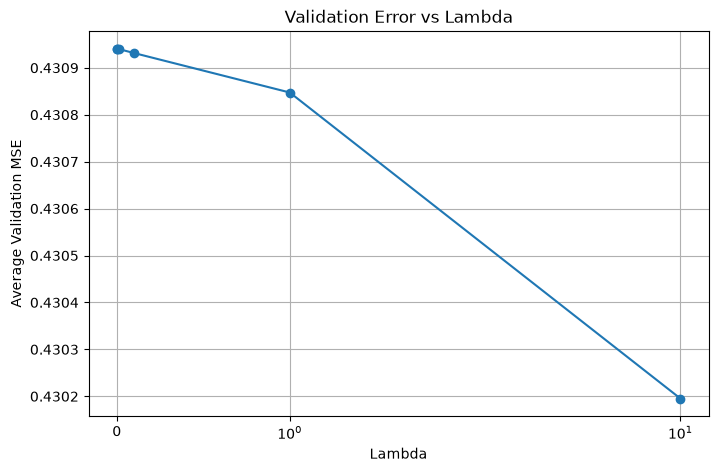

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    cv_results_df["Lambda"],
    cv_results_df["Average Validation MSE"],
    marker="o"
)

plt.xscale("symlog")
plt.xlabel("Lambda")
plt.ylabel("Average Validation MSE")
plt.title("Validation Error vs Lambda")
plt.grid(True)

plt.show()

In [23]:
training_errors = []

for lam in lambda_values:

    weights = ridge_regression(
        X_train_with_intercept,
        y_train,
        lam
    )

    predictions = predict(
        X_train_with_intercept,
        weights
    )

    error = mean_squared_error(
        y_train,
        predictions
    )

    training_errors.append(error)

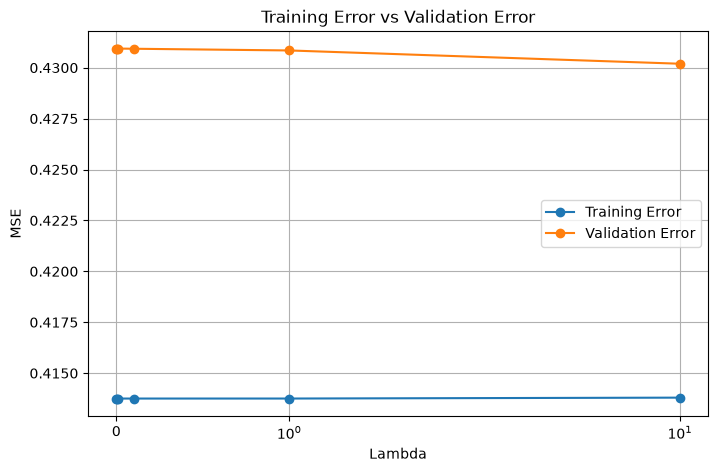

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    lambda_values,
    training_errors,
    marker="o",
    label="Training Error"
)

plt.plot(
    lambda_values,
    cv_results_df["Average Validation MSE"],
    marker="o",
    label="Validation Error"
)

plt.xscale("symlog")
plt.xlabel("Lambda")
plt.ylabel("MSE")
plt.title("Training Error vs Validation Error")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
# Linear Regression
linear_weights = ridge_regression(
    X_train_with_intercept,
    y_train,
    0
)

# Ridge with optimal lambda
optimal_weights = ridge_regression(
    X_train_with_intercept,
    y_train,
    best_lambda
)

# Ridge with very high lambda
high_lambda_weights = ridge_regression(
    X_train_with_intercept,
    y_train,
    1000
)

In [26]:
linear_predictions = predict(
    X_test_with_intercept,
    linear_weights
)

optimal_predictions = predict(
    X_test_with_intercept,
    optimal_weights
)

high_lambda_predictions = predict(
    X_test_with_intercept,
    high_lambda_weights
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

optimal_mse = mean_squared_error(
    y_test,
    optimal_predictions
)

high_lambda_mse = mean_squared_error(
    y_test,
    high_lambda_predictions
)

In [27]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge - Optimal Lambda",
        "Ridge - High Lambda"
    ],
    "Test MSE": [
        linear_mse,
        optimal_mse,
        high_lambda_mse
    ]
})

model_comparison

,Model,Test MSE
0,Linear Regression,0.377017
1,Ridge - Optimal Lambda,0.376168
2,Ridge - High Lambda,0.400538


In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": np.abs(linear_weights[1:]),
    "Ridge Optimal": np.abs(optimal_weights[1:]),
    "Ridge High Lambda": np.abs(high_lambda_weights[1:])
})

importance

,Feature,Linear Regression,Ridge Optimal,Ridge High Lambda
0,fixed acidity,0.029500,0.037131,0.032023
1,volatile acidity,0.195679,0.192494,0.108811
2,citric acid,0.036365,0.031086,0.043258
3,residual sugar,0.007610,0.010521,0.010809
4,chlorides,0.099180,0.098270,0.051164
5,free sulfur dioxide,0.020763,0.019330,0.006370
6,total sulfur dioxide,0.089363,0.088420,0.048012
7,density,0.021219,0.031252,0.052373
8,pH,0.084377,0.076886,0.012842
9,sulphates,0.153460,0.153163,0.081597


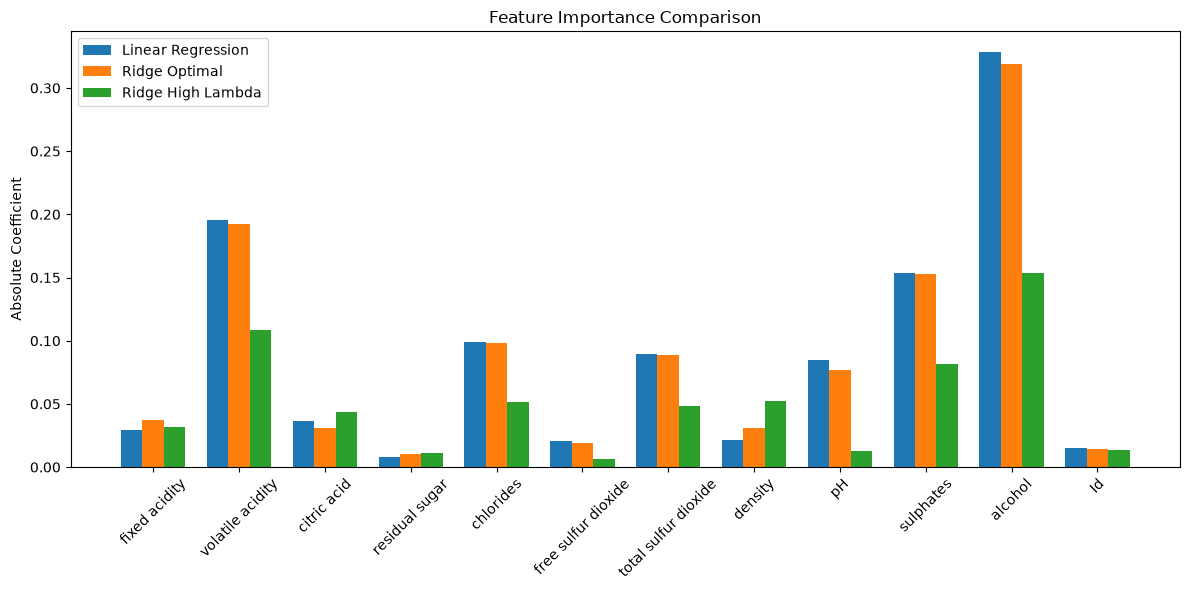

In [29]:
x = np.arange(len(X.columns))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    importance["Linear Regression"],
    width,
    label="Linear Regression"
)

plt.bar(
    x,
    importance["Ridge Optimal"],
    width,
    label="Ridge Optimal"
)

plt.bar(
    x + width,
    importance["Ridge High Lambda"],
    width,
    label="Ridge High Lambda"
)

plt.xticks(
    x,
    X.columns,
    rotation=45
)

plt.ylabel("Absolute Coefficient")
plt.title("Feature Importance Comparison")
plt.legend()
plt.tight_layout()

plt.show()

In [30]:
importance_sorted = importance.sort_values(
    by="Ridge Optimal",
    ascending=False
)

importance_sorted

,Feature,Linear Regression,Ridge Optimal,Ridge High Lambda
10,alcohol,0.328391,0.318666,0.153587
1,volatile acidity,0.195679,0.192494,0.108811
9,sulphates,0.153460,0.153163,0.081597
4,chlorides,0.099180,0.098270,0.051164
6,total sulfur dioxide,0.089363,0.088420,0.048012
8,pH,0.084377,0.076886,0.012842
0,fixed acidity,0.029500,0.037131,0.032023
7,density,0.021219,0.031252,0.052373
2,citric acid,0.036365,0.031086,0.043258
5,free sulfur dioxide,0.020763,0.019330,0.006370


In [31]:
most_important = importance_sorted.iloc[0]

print(
    "Most important feature:",
    most_important["Feature"]
)

print(
    "Coefficient:",
    optimal_weights[
        list(X.columns).index(most_important["Feature"]) + 1
    ]
)

Most important feature: alcohol
Coefficient: 0.3186661885500649
